In [1]:
%matplotlib inline

import importlib
import numpy as np
import make_frames as mf
from matplotlib.colors import SymLogNorm

# Regridding weights and topography: expensive, and they never change.
W, nlat, nlon, lat1d, lon1d = mf.mec.make_regridder(mf.WGTFILE)

import xarray as xr
with xr.open_dataset(mf.FTOPO) as Topo:
    htopo = Topo.PHIS.values / 9.8
topo_yx = mf.regrid(htopo, W, nlat, nlon)
topo_c  = mf.make_topo_overlay(topo_yx, lat1d, lon1d, f=4)

dates = mf.build_dates([2016, 8, 1, 3], nsteps=247, step_size=3)
print(nlat, nlon, len(dates))

 a path to /glade/work/juliob added in Utils.numerical_utils 
Regridder ready: 3600 lat x 12410 lon
  lat: -80.000 to 0.000 deg
  lon: 0.000 to 359.971 deg
3600 12410 247


In [2]:
importlib.reload( mf )

<module 'make_frames' from '/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/make_frames.py'>

In [3]:
date_str = dates[20]          # pick any index you like

fd = mf.load_frame_data(
    date_str,
    fields=["w_mpas_prt", "U", "V","PRECL"],   # U,V only needed for the vorticity test
    levels=mf.LEVELS,
    W=W, nlat=nlat, nlon=nlon,
    lat1d=lat1d, lon1d=lon1d,
    topo_yx=topo_yx,
    casedir=mf.CASEDIR,
)
print(fd.w_mpas_prt.shape)

  opened /glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-03-54000/w_mpas_prt_dyamond.2016-08-03-54000.nc  dims=('time', 'ilev', 'ncol')
  opened /glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-03-54000/U_dyamond.nc  dims=('time', 'lev', 'ncol')
  opened /glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-03-54000/V_dyamond.nc  dims=('time', 'lev', 'ncol')
  opened /glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-03-54000/PRECL_dyamond.nc  dims=('time', 'ncol')
(1, 4, 3600, 12410)


In [4]:
it, iz = 0, 0

zeta2d = mf.nuti.Sphere_Curl2(
    f_x=fd.U[it, iz, :, :], f_y=fd.V[it, iz, :, :],
    lat=lat1d, lon=lon1d, wrap=True, verbose=False,
)
print(np.nanpercentile(np.abs(zeta2d), [50, 90, 99]))

prec_scale = 1_000. * 86_400.
print(np.nanpercentile( prec_scale * fd.PRECL[it,:,:] , [50, 90, 99]))

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


[3.40069337e-05 1.21872905e-04 3.98601864e-04]
[2.23671280e-05 2.13203948e+00 5.28458076e+01]


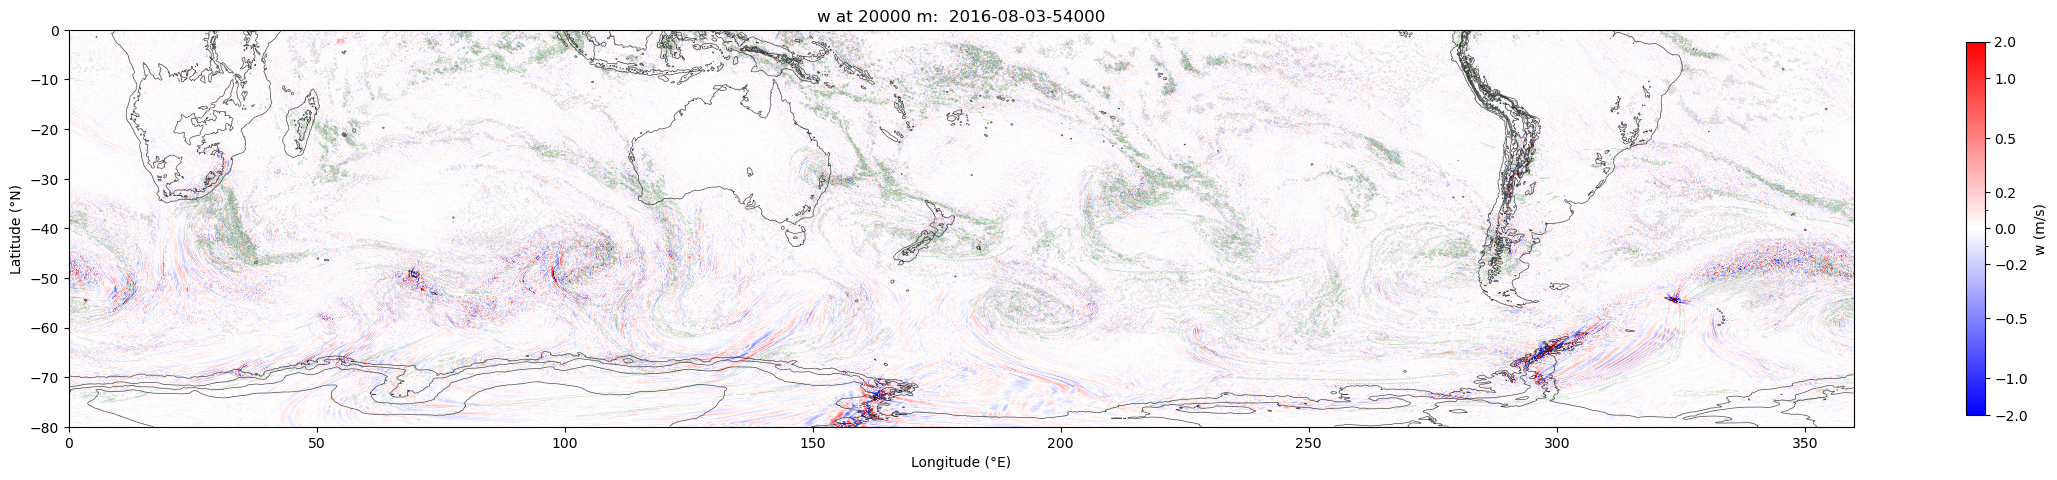

In [5]:
importlib.reload( mf )
from matplotlib.ticker import ScalarFormatter

ticks = [-2, -1, -0.5, -0.2, 0, 0.2, 0.5, 1, 2]

#norm = SymLogNorm(linthresh=1.0, vmin=-5, vmax=5)
#norm = SymLogNorm(linthresh=1.0, vmin=-2, vmax=2)
#norm = SymLogNorm(linthresh=0.5, vmin=-2, vmax=2)
norm = SymLogNorm(linthresh=0.75, vmin=-2, vmax=2)

it,iz = 0,3

fig, ax = mf.render_frame(
    fd.w_mpas_prt[it, iz, :, :],
    lat1d, lon1d, topo_c, norm,
    outfile=None,                       # None -> display, don't save
    title=f"w at {mf.LEVELS[iz]} m:  {date_str}",
    label="w (m/s)",
    cbar_ticks=ticks,
    cbar_format=ScalarFormatter(),
    zeta=zeta2d,                        # drop this line to see it without
    zeta_levels=[-2e-4, 2e-4],          # set from the percentiles above
    zeta_coarsen=4,
    zeta_color="g",
    zeta_alpha=0.25,
    prec=prec_scale * fd.PRECL[it,:,:], # drop this line to see it without
    prec_levels=[3.,25.],          # set from the percentiles above
    prec_coarsen=4,
    prec_color="gray",
    prec_alpha=0.2,
)

#ax.set_xlim(50, 150)                    # zoom while you experiment